# NetShield AI - Enterprise ML Pipeline
This notebook implements the final Random Forest pipeline for the NetShield AI cybersecurity project. It features rigorous methodology including mathematically sound test-set isolation, untouched real-world distribution evaluation, and Level 1/Level 2 threat detection metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
from sklearn.ensemble import RandomForestClassifier

plt.style.use('dark_background')
sns.set_palette('muted')

## 1. Load Data

In [2]:
dataset_dir = r'D:\Infosys\2017_improved'
all_files = glob.glob(os.path.join(dataset_dir, '*.csv'))

df_list = []
for file in all_files:
    print(f'Loading {os.path.basename(file)}...')
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(f'\nTotal combined shape: {df.shape}')

Loading friday.csv...
Loading monday.csv...
Loading thursday.csv...
Loading tuesday.csv...
Loading wednesday.csv...

Total combined shape: (2099976, 91)


## 2. Cleaning & Deduplication

In [3]:
# Remove identifiers and network-specific fields that may allow
# memorization of individual flows or network-specific artifacts.
feature_drop = [
    'attempted_category',
    'id',
    'timestamp',
    'flow_id',
    'src_ip',
    'dst_ip',
    'src_port',
    'dst_port',
    'protocol'
]
df = df.drop(columns=[col for col in feature_drop if col in df.columns], errors='ignore')

# Clean invalid data
df = df.replace([np.inf, -np.inf], np.nan).dropna()

initial_rows = len(df)
df = df.drop_duplicates()
dropped = initial_rows - len(df)
print(f'Dropped {dropped} duplicate rows ({(dropped/initial_rows)*100:.2f}% of dataset).\nNew shape: {df.shape}')

Dropped 384630 duplicate rows (18.32% of dataset).
New shape: (1715341, 82)


## 3. Label Grouping

In [4]:
print("Merging fragmented attack classes before splitting...")
df['label'] = df['label'].replace({
    'Infiltration - Attempted': 'Infiltration',
    'Infiltration - Portscan': 'Infiltration',
    'FTP-Patator - Attempted': 'FTP-Patator',
    'SSH-Patator - Attempted': 'SSH-Patator',
    'DoS GoldenEye - Attempted': 'DoS GoldenEye',
    'DoS Hulk - Attempted': 'DoS Hulk',
    'DoS Slowhttptest - Attempted': 'DoS Slowhttptest',
    'DoS Slowloris - Attempted': 'DoS Slowloris',
    'Botnet - Attempted': 'Botnet',
    'Web Attack - Brute Force': 'Web Attack',
    'Web Attack - Brute Force - Attempted': 'Web Attack',
    'Web Attack - SQL Injection': 'Web Attack',
    'Web Attack - SQL Injection - Attempted': 'Web Attack',
    'Web Attack - XSS': 'Web Attack',
    'Web Attack - XSS - Attempted': 'Web Attack'
})

print(df['label'].value_counts())

Merging fragmented attack classes before splitting...
label
BENIGN              1423827
DoS Hulk             159048
DDoS                  95144
DoS GoldenEye          7647
Infiltration           6208
DoS Slowloris          5703
DoS Slowhttptest       5108
FTP-Patator            3984
SSH-Patator            2988
Web Attack             2056
Botnet                 1934
Portscan               1683
Heartbleed               11
Name: count, dtype: int64


## 4. Train/Test Split 

In [5]:
print("Performing Train/Test split on the FULL dataset...")
# Extract X and y before splitting to ensure no data leakage
X_raw = df.drop(columns=['label'], errors='ignore')
X_raw = X_raw.select_dtypes(include=[np.number]).fillna(0)
y_raw = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
print(f"Initial Training Set: {X_train.shape[0]} rows")
print(f"Initial Test Set: {X_test.shape[0]} rows")

Performing Train/Test split on the FULL dataset...
Initial Training Set: 1372272 rows
Initial Test Set: 343069 rows


## 5. Balance Training Data ONLY

In [6]:
print("Downsampling BENIGN class in the TRAINING set only...")

# Recombine X_train and y_train temporarily to balance
train_df = X_train.copy()
train_df['label'] = y_train

# Downsample BENIGN
train_benign = train_df[train_df['label'] == 'BENIGN']
train_attack = train_df[train_df['label'] != 'BENIGN']

# Sample without replacement since we have more than enough rows
if len(train_benign) > 200000:
    train_benign = train_benign.sample(n=200000, random_state=42, replace=False)
else:
    train_benign = train_benign.sample(n=len(train_benign), random_state=42, replace=False)

train_balanced = pd.concat([train_benign, train_attack]).sample(frac=1, random_state=42).reset_index(drop=True)

# Separate back into X_train, y_train
y_train_balanced = train_balanced['label']
X_train_balanced = train_balanced.drop(columns=['label'])

print(f"Balanced Training Set Shape: {X_train_balanced.shape}")

# Encode the labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_balanced)
y_test_enc = le.transform(y_test) # Encode untouched test set using the same encoder

Downsampling BENIGN class in the TRAINING set only...
Balanced Training Set Shape: (433211, 81)


## 6. Train Random Forest

In [7]:
print("Training Random Forest Classifier (Champion Model)...")
print("Using class_weight='balanced' to increase the training penalty for misclassifications involving minority classes.")


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,           
    class_weight='balanced',  
    n_jobs=-1,                
    random_state=42
)

model.fit(X_train_balanced, y_train_enc)

print("Predicting on test set...")
y_pred_enc = model.predict(X_test)
print("Done!")

Training Random Forest Classifier (Champion Model)...
Using class_weight='balanced' to increase the training penalty for misclassifications involving minority classes.
Predicting on test set...
Done!


## 7. Advanced NetShield Evaluation

Overall Accuracy: 0.9993

📊 STANDARD ML CLASSIFICATION REPORT (Precision/Recall/F1) 📊
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    284766
          Botnet       0.86      0.96      0.91       387
            DDoS       1.00      1.00      1.00     19029
   DoS GoldenEye       1.00      1.00      1.00      1529
        DoS Hulk       1.00      1.00      1.00     31810
DoS Slowhttptest       0.94      0.99      0.97      1022
   DoS Slowloris       1.00      1.00      1.00      1141
     FTP-Patator       1.00      1.00      1.00       797
      Heartbleed       0.67      1.00      0.80         2
    Infiltration       0.97      0.98      0.98      1242
        Portscan       0.94      0.93      0.93       336
     SSH-Patator       1.00      0.99      1.00       597
      Web Attack       0.99      0.98      0.99       411

        accuracy                           1.00    343069
       macro avg       0.95      0.99     

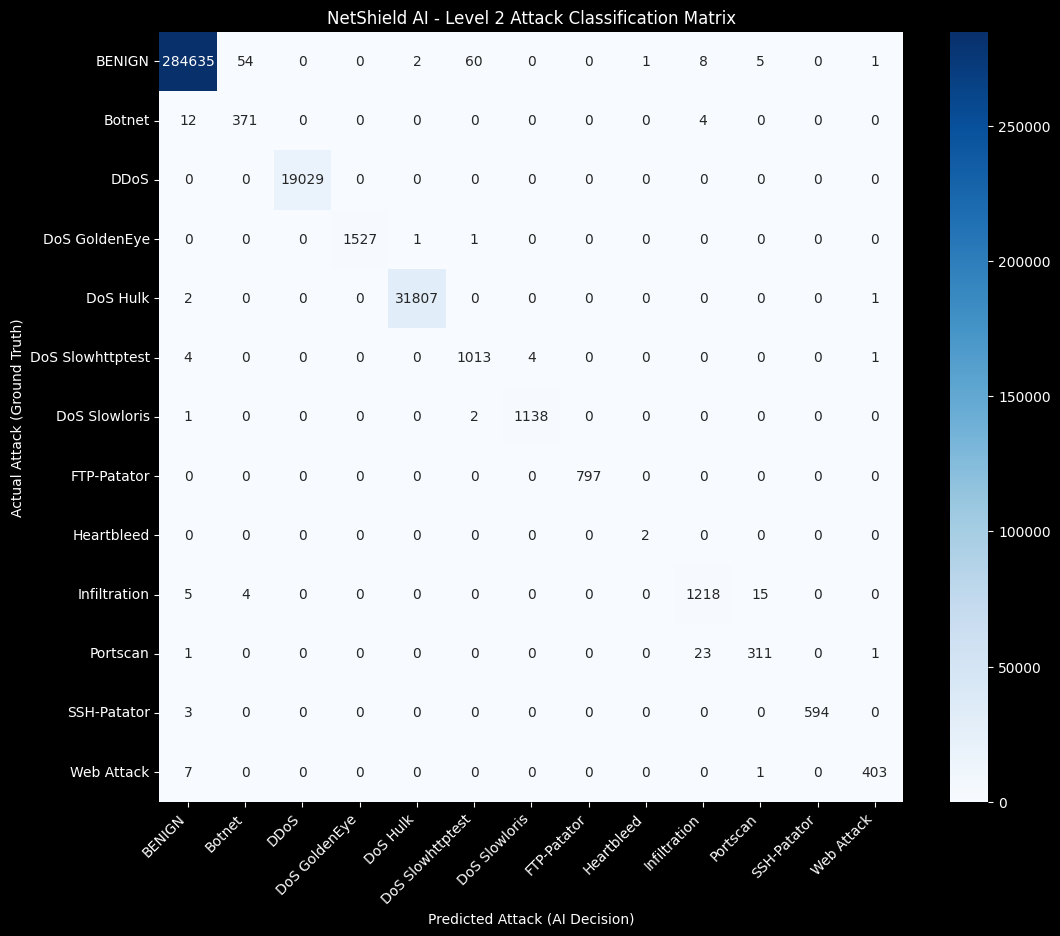

In [8]:
print(f'Overall Accuracy: {accuracy_score(y_test_enc, y_pred_enc):.4f}\n')

print("="*50)
print("📊 STANDARD ML CLASSIFICATION REPORT (Precision/Recall/F1) 📊")
print("="*50)
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))


# 1. Level 1: Binary Security Metrics (Benign vs Malicious)
print("="*50)
print("🛡️ LEVEL 1: IS THIS TRAFFIC MALICIOUS? 🛡️")
print("="*50)

benign_idx = le.transform(['BENIGN'])[0]
y_test_binary = (y_test_enc != benign_idx).astype(int)
y_pred_binary = (y_pred_enc != benign_idx).astype(int)
binary_cm = confusion_matrix(y_test_binary, y_pred_binary)

TN, FP, FN, TP = binary_cm.ravel()
bin_TDR = TP / (TP + FN) if (TP + FN) > 0 else 0
bin_FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
bin_FNR = FN / (FN + TP) if (FN + TP) > 0 else 0

print(f"Malicious Traffic TDR: {bin_TDR*100:.2f}%")
print(f"Malicious Traffic FPR: {bin_FPR*100:.4f}%")
print(f"Malicious Traffic FNR: {bin_FNR*100:.4f}%")

# 2. Attack-Only TDR
attack_mask = y_test_enc != benign_idx
attack_tdr = recall_score(y_test_enc[attack_mask], y_pred_enc[attack_mask], average='micro')
print(f"\nMalicious-Sample Classification TDR (Micro Recall): {attack_tdr * 100:.2f}%")

macro_tdr = recall_score(y_test_enc, y_pred_enc, average='macro')
weighted_tdr = recall_score(y_test_enc, y_pred_enc, average='weighted')
print(f"Macro TDR (Recall):    {macro_tdr * 100:.2f}%")
print(f"Weighted TDR (Recall): {weighted_tdr * 100:.2f}%\n")

# 3. Level 2: Specific Attack Classification
print("="*50)
print("🛡️ LEVEL 2: SPECIFIC ATTACK CLASSIFICATION 🛡️")
print("="*50)

cm = confusion_matrix(y_test_enc, y_pred_enc)

print(f"{'Class':<20} | {'Support':<8} | {'TDR (Recall)':<12} | {'FPR':<8} | {'FNR':<8}")
print("-" * 65)

for i, class_name in enumerate(le.classes_):
    TP_c = cm[i, i]
    FP_c = cm[:, i].sum() - TP_c
    FN_c = cm[i, :].sum() - TP_c
    TN_c = cm.sum() - (TP_c + FP_c + FN_c)
    
    Support = cm[i, :].sum()
    
    FPR_c = FP_c / (FP_c + TN_c) if (FP_c + TN_c) > 0 else 0
    FNR_c = FN_c / (FN_c + TP_c) if (FN_c + TP_c) > 0 else 0
    TDR_c = TP_c / (TP_c + FN_c) if (TP_c + FN_c) > 0 else 0
    
    print(f"{class_name:<20} | {Support:<8} | {TDR_c*100:>6.2f}%      | {FPR_c*100:>5.2f}% | {FNR_c*100:>5.2f}%")

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('NetShield AI - Level 2 Attack Classification Matrix')
plt.ylabel('Actual Attack (Ground Truth)')
plt.xlabel('Predicted Attack (AI Decision)')
plt.xticks(rotation=45, ha='right')
plt.show()

## 8. Save Pipeline

In [14]:
os.makedirs(r'd:\Infosys\backend\ml\saved_models', exist_ok=True)

# Save the exact feature names to ensure the live sniffer aligns its columns perfectly
feature_names = X_train_balanced.columns.tolist()
joblib.dump(feature_names, r'd:\Infosys\backend\ml\saved_models\feature_names.pkl')

joblib.dump(model, r'd:\Infosys\backend\ml\saved_models\f_multiclass.pkl')
joblib.dump(le, r'd:\Infosys\backend\ml\saved_models\label_encoder.pkl')

print('NetShield AI Pipeline saved successfully!')
print(f'Exported {len(feature_names)} strictly ordered feature names for live sniffer alignment.')

NetShield AI Pipeline saved successfully!
Exported 81 strictly ordered feature names for live sniffer alignment.
